In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])


32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
block_size = 3 # context length: how many characters do we take to predict the next one
# build the dataset
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%


In [90]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print("".join(itos[i.item()] for i in x), "->", itos[y.item()])

... -> y
..y -> u
.yu -> h
yuh -> e
uhe -> n
hen -> g
eng -> .
... -> d
..d -> i
.di -> o
dio -> n
ion -> d
ond -> r
ndr -> e
dre -> .
... -> x
..x -> a
.xa -> v
xav -> i
avi -> e


In [91]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_out, fan_in)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight.T
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running `momentum update`)
        # exponential moving average
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
    def buffers(self):
        return [self.running_mean, self.running_var]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [92]:
torch.manual_seed(42) # seed rng for reproducibility

In [93]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

C = torch.randn((vocab_size, n_embd))
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

# parameters init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last year make less confident

parameters = [C] + [p for l in layers for p in l.parameters()]
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


12097


      0/ 200000 3.2747
   1000/ 200000 2.5430
   2000/ 200000 2.1362
   3000/ 200000 2.1263
   4000/ 200000 2.7063
   5000/ 200000 2.2054
   6000/ 200000 2.4543
   7000/ 200000 2.1125
   8000/ 200000 2.0654
   9000/ 200000 2.6900
  10000/ 200000 2.2115
  11000/ 200000 2.2742
  12000/ 200000 2.6416
  13000/ 200000 2.3810
  14000/ 200000 2.3133
  15000/ 200000 2.3740
  16000/ 200000 2.2598
  17000/ 200000 2.2402
  18000/ 200000 2.2649
  19000/ 200000 2.4419
  20000/ 200000 2.3646
  21000/ 200000 2.0378
  22000/ 200000 2.0236
  23000/ 200000 2.0963
  24000/ 200000 2.3230
  25000/ 200000 1.8510
  26000/ 200000 2.0725
  27000/ 200000 2.2269
  28000/ 200000 2.3394
  29000/ 200000 2.1206
  30000/ 200000 2.0592
  31000/ 200000 1.9211
  32000/ 200000 2.0927
  33000/ 200000 2.3068
  34000/ 200000 1.7871
  35000/ 200000 2.3927
  36000/ 200000 2.2447
  37000/ 200000 1.9208
  38000/ 200000 2.2712
  39000/ 200000 2.0582
  40000/ 200000 2.3064
  41000/ 200000 2.0137
  42000/ 200000 1.8704
  43000/ 20

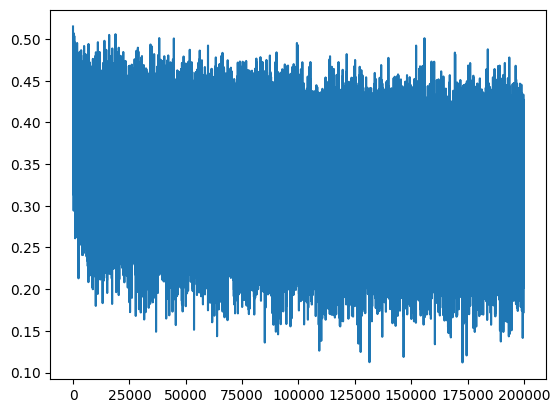

In [94]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # flatten the batch of embeddings
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad
    # exponential moving average of the loss
    lossi.append(loss.log10().item())

    # track stats
    if i % 1000 == 0:
        print(f"{i:7d}/{max_steps:7d} {loss.item():.4f}")

# plot the loss
plt.plot(lossi)
        

In [95]:
# put layers into eval mode (needed for batchnorm especially)
for layer in layers:
    layer.training = False

In [96]:
# evaluate the loss
@torch.no_grad()  # this decorator disables gradient tracking inside pytorch
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(f"{split}: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train: 2.0626
val: 2.1084


In [97]:
# sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural next
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        x = emb.view(emb.shape[0], -1) # concatenate the vectors
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=-1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # update the context
        context = context[1:] + [ix]
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(itos[ix])
        # break if we hit a ... or EOS token
        if ix == 0:
            break
    print("".join(out))
        
        

imovi.
adian.
th.
ommasahemaz.
mopyanyesala.
ale.
mi.
kel.
biian.
peso.
carilon.
jit.
jodre.
arodriahi.
as.
viakyanaarianiana.
vi.
co.
vene.
pifela.


# Step1 fix the plt.plot(lossi)

In [98]:
print(torch.arange(10).view(2, 5))
print(torch.tensor(lossi).view(-1, 1000).shape)
print(torch.tensor(lossi).view(-1,1000).mean(1).shape)


tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])
torch.Size([200, 1000])
torch.Size([200])


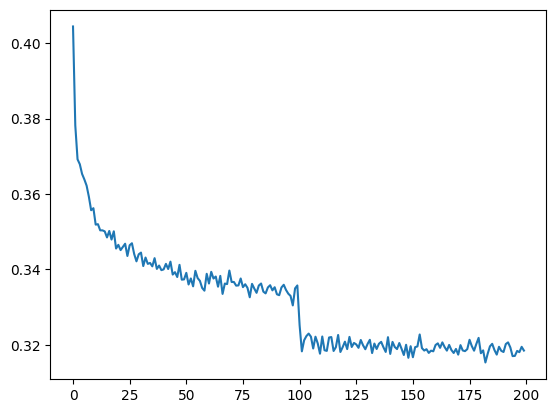

In [99]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

# Step 2 Fixing layers
- make layers to incorperate `C = torch.randn((vocab_size, n_embd))`
- make layers to incorperate `emb = C[Xb]; x = emb.view(emb.shape[0], -1)`

In [100]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_out, fan_in)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight.T
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running `momentum update`)
        # exponential moving average
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
    def buffers(self):
        return [self.running_mean, self.running_var]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

#--------------------------------
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
        
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
#--------------------------------
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []



In [101]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

# C = torch.randn((vocab_size, n_embd))
layers = [
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

# parameters init
with torch.no_grad():
    layers[-1].weight *= 0.1 # last year make less confident

parameters = [p for l in layers for p in l.parameters()]
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


12097


      0/ 200000 3.2919
   1000/ 200000 2.5618
   2000/ 200000 2.2548
   3000/ 200000 2.4086
   4000/ 200000 1.9530
   5000/ 200000 2.1781
   6000/ 200000 2.2529
   7000/ 200000 2.3171
   8000/ 200000 2.2302
   9000/ 200000 1.8853
  10000/ 200000 1.7548
  11000/ 200000 2.1661
  12000/ 200000 2.4778
  13000/ 200000 1.9883
  14000/ 200000 2.5550
  15000/ 200000 2.6595
  16000/ 200000 2.2391
  17000/ 200000 2.1291
  18000/ 200000 2.2539
  19000/ 200000 2.4119
  20000/ 200000 2.1155
  21000/ 200000 2.1071
  22000/ 200000 2.1614
  23000/ 200000 2.1429
  24000/ 200000 2.0258
  25000/ 200000 2.3073
  26000/ 200000 2.4938
  27000/ 200000 1.9136
  28000/ 200000 2.0597
  29000/ 200000 1.9794
  30000/ 200000 2.0672
  31000/ 200000 2.2969
  32000/ 200000 2.0327
  33000/ 200000 2.4700
  34000/ 200000 1.7933
  35000/ 200000 2.2483
  36000/ 200000 2.1994
  37000/ 200000 2.2760
  38000/ 200000 1.9517
  39000/ 200000 2.3140
  40000/ 200000 2.0699
  41000/ 200000 2.0723
  42000/ 200000 2.2562
  43000/ 20

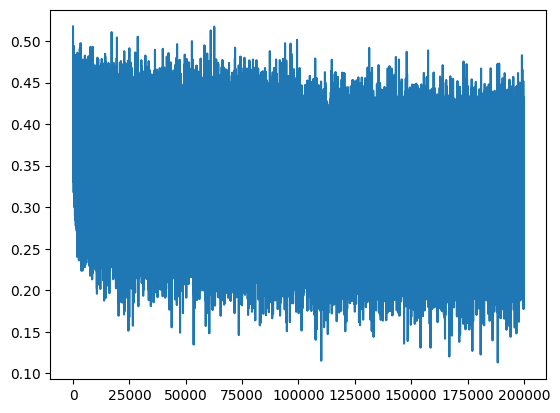

In [102]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    # forward pass
    # emb = C[Xb] # embed the characters into vectors
    # x = emb.view(emb.shape[0], -1) # flatten the batch of embeddings
    x = Xb
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad
    # exponential moving average of the loss
    lossi.append(loss.log10().item())

    # track stats
    if i % 1000 == 0:
        print(f"{i:7d}/{max_steps:7d} {loss.item():.4f}")

# plot the loss
plt.plot(lossi)
        

# Step 3 Create Containers

In [103]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_out, fan_in)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight.T
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running `momentum update`)
        # exponential moving average
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
    def buffers(self):
        return [self.running_mean, self.running_var]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

#--------------------------------
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
        
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
#--------------------------------
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []


#--------------------------------
class Sequential:
    def __init__(self, layers):
        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]
        

In [ ]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

# C = torch.randn((vocab_size, n_embd))
model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

# parameters init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # last year make less confident

parameters = model.parameters()
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


12097


      0/ 200000 3.4886
   1000/ 200000 2.0627
   2000/ 200000 2.4143
   3000/ 200000 2.2963
   4000/ 200000 2.2521
   5000/ 200000 2.0284
   6000/ 200000 2.1441
   7000/ 200000 2.5403
   8000/ 200000 2.2359
   9000/ 200000 2.0320
  10000/ 200000 2.1731
  11000/ 200000 2.2178
  12000/ 200000 2.2997
  13000/ 200000 2.2103
  14000/ 200000 2.1818
  15000/ 200000 1.9429
  16000/ 200000 1.9717
  17000/ 200000 2.0538
  18000/ 200000 2.3024
  19000/ 200000 2.1406
  20000/ 200000 2.1355
  21000/ 200000 2.0509
  22000/ 200000 2.3326
  23000/ 200000 2.6115
  24000/ 200000 2.4330
  25000/ 200000 2.2327
  26000/ 200000 2.3578
  27000/ 200000 2.0280
  28000/ 200000 2.4535
  29000/ 200000 2.1606
  30000/ 200000 2.1840
  31000/ 200000 2.3156
  32000/ 200000 2.4384
  33000/ 200000 2.2166
  34000/ 200000 2.5456
  35000/ 200000 2.1202
  36000/ 200000 2.4690
  37000/ 200000 2.2066
  38000/ 200000 1.9493
  39000/ 200000 2.2937
  40000/ 200000 2.1976
  41000/ 200000 2.4085
  42000/ 200000 2.0638
  43000/ 20

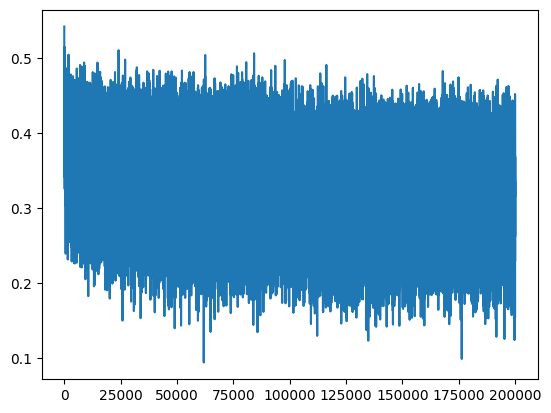

In [105]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    # forward pass
    # emb = C[Xb] # embed the characters into vectors
    # x = emb.view(emb.shape[0], -1) # flatten the batch of embeddings
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad
    # exponential moving average of the loss
    lossi.append(loss.log10().item())

    # track stats
    if i % 1000 == 0:
        print(f"{i:7d}/{max_steps:7d} {loss.item():.4f}")

# plot the loss
plt.plot(lossi)
        

In [106]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [107]:
# sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=-1)
        # print(probs)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))


chent.
glida.
sterier.
raveelaa.
azly.
faislan.
terrisell.
madrialys.
emmy.
ojaleia.
malynn.
syprissenawdor.
raynacha.
mari.
taviy.
avio.
jamayan.
welleya.
kiha.
lucct.


# Step 4 Create WaveNet

In [6]:
block_size = 8 # context length: how many characters do we take to predict the next one
# build the dataset
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%

In [109]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print("".join(itos[i.item()] for i in x), "->", itos[y.item()])

........ -> e
.......e -> b
......eb -> r
.....ebr -> i
....ebri -> m
...ebrim -> a
..ebrima -> .
........ -> h
.......h -> i
......hi -> l
.....hil -> t
....hilt -> o
...hilto -> n
..hilton -> .
........ -> j
.......j -> h
......jh -> e
.....jhe -> n
....jhen -> e
...jhene -> .


In [ ]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

# C = torch.randn((vocab_size, n_embd))
model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

# parameters init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # last year make less confident

parameters = model.parameters()
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


22097


In [111]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # let's look at a batch of just 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb


torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0, 22],
        [ 0,  0,  0,  0,  0,  0,  2, 12],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0, 13,  5,  7,  8,  1]])

In [ ]:
model.layers[0].out.shape # output of the embedding layer

torch.Size([4, 8, 10])

In [ ]:
model.layers[1].out.shape # output of flatten layer

torch.Size([4, 80])

In [114]:
model.layers[2].out.shape # output of the linear layer

torch.Size([4, 200])

In [116]:
# more details in the linear layer
print((torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape)
print((torch.randn(4, 5, 80) @ torch.randn(80, 200) + torch.randn(200)).shape)

torch.Size([4, 200])
torch.Size([4, 5, 200])


In [124]:
# so now we don't want to flatten the 8 characters into a single vector
# we want to group the 8 characters into 4 groups of 2 characters each, e.g, (1 2) (3 4) (5 6) (7 8)
# background knowledge for list operations in python
print(list(range(10))[1::2]) # [1, 3, 5, 7, 9]
print(list(range(10))[::2]) # [0, 2, 4, 6, 8]
# so we can do this for the 8 characters
e = torch.randn(4, 8, 10) # goal: want this to be (4, 4, 20) where consecutive 10-d vectors get concatenated
# torch.cat((e[:, ::2, :], e[:, 1::2, :]), dim=2).shape
explicit = torch.cat((e[:, ::2, :], e[:, 1::2, :]), dim=2)
print(explicit.shape)


[1, 3, 5, 7, 9]
[0, 2, 4, 6, 8]
torch.Size([4, 4, 20])


In [125]:
# alternative way   
(e.view(4, 4, 20) == explicit).all()

tensor(True)

## Enhance Flattern

In [26]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_out, fan_in)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight.T
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running `momentum update`)
        # exponential moving average
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
    def buffers(self):
        return [self.running_mean, self.running_var]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

#--------------------------------
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
        
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
#--------------------------------
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n # number of groups
    
    def __call__(self, x):
        B, T, C = x.shape # B: batch size, T: sequence length, C: embedding dimension
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []


#--------------------------------
class Sequential:
    def __init__(self, layers):
        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]
        

In [27]:
torch.manual_seed(42); # seed rng for reproducibility

In [28]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

# C = torch.randn((vocab_size, n_embd))
model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(block_size), # recover previous behavior
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

# parameters init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


22097


In [40]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # let's look at a batch of just 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  1,  9],
        [ 0,  0,  0,  0,  8, 21, 19,  1],
        [ 0,  0,  0, 11,  9, 14,  7,  4],
        [ 0,  0,  0,  0,  0,  0,  0, 20]])

In [41]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


## Continue update flattern group

In [39]:
n_embd = 10 # the dimension of the embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of MLP
# change from 200 to 68 so that the parameters are exactly same as before

# C = torch.randn((vocab_size, n_embd))
model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),  Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

# parameters init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.numel() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


22397


## Detect the batchnorm layer bug
### when we calculate xmean and xvar, we only assume that the it's 2 dimentional

In [45]:
# problem here
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim=True) # 1, 4, 68
evar = e.var(0, keepdim=True) # 1, 4, 68
print(emean.shape)
print(evar.shape)
ehat = (e - emean) / torch.sqrt(evar + 1e-5) # 32, 4, 68
print(ehat.shape)

# correct way
emean = e.mean((0, 1), keepdim=True) # 1, 1, 68
evar = e.var((0, 1), keepdim=True) # 1, 1, 68
print(emean.shape)
print(evar.shape)
ehat = (e - emean) / torch.sqrt(evar + 1e-5) # 32, 4, 68
print(ehat.shape)


torch.Size([1, 4, 68])
torch.Size([1, 4, 68])
torch.Size([32, 4, 68])
torch.Size([1, 1, 68])
torch.Size([1, 1, 68])
torch.Size([32, 4, 68])


## Add fix for batchnorm

In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_out, fan_in)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight.T
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running `momentum update`)
        # exponential moving average
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True) # batch mean
            xvar = x.var(dim, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
    def buffers(self):
        return [self.running_mean, self.running_var]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

#--------------------------------
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
        
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
#--------------------------------
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n # number of groups
    
    def __call__(self, x):
        B, T, C = x.shape # B: batch size, T: sequence length, C: embedding dimension
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []


#--------------------------------
class Sequential:
    def __init__(self, layers):
        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]
        